# Bangladesh Airbnb — Exploratory Data Analysis (v2)

Overview, distributions, cross-tabulations, correlation, and review trends on
the rebuilt `final_data/*.csv` + `data/processed/reviews.csv` outputs from
`run_pipeline.py`. Superseeds the old, unfinished `notebooks/eda.ipynb`.

Scope: broad understanding of the dataset before building the local
decision-support module — not a deep-dive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

VALID_BD_DIVISIONS = [
    "Dhaka Division", "Chittagong", "Sylhet Division", "Rajshahi Division",
    "Barisal Division", "Khulna Division", "Rangpur Division", "Mymensingh Division",
]

## 1. Load data

In [2]:
listings = pd.read_csv("../final_data/listings.csv")
hosts = pd.read_csv("../final_data/hosts.csv")
facilities = pd.read_csv("../final_data/facilities.csv")
reviews = pd.read_csv("../data/processed/reviews.csv", parse_dates=["review_date"])

# bedrooms/beds/baths/listing_rating are stored as text (see clean.py); coerce
# to numeric here so a residual unparseable value becomes NaN, not a crash.
for col in ["bedrooms", "beds", "baths", "listing_rating"]:
    listings[col] = pd.to_numeric(listings[col], errors="coerce")

listings["is_bd_division"] = listings["principalSubdivision"].isin(VALID_BD_DIVISIONS)
bd = listings[listings["is_bd_division"]].copy()

print(f"listings: {listings.shape}  (BD-division: {len(bd)})")
print(f"hosts: {hosts.shape}")
print(f"facilities: {facilities.shape}")
print(f"reviews: {reviews.shape}  covering {reviews['base_urls'].nunique()} listings")

listings: (1556, 27)  (BD-division: 1348)
hosts: (849, 12)
facilities: (1565, 40)
reviews: (3898, 6)  covering 520 listings


## 2. Overview & data completeness

Numeric parsing note: `bedrooms`/`beds`/`baths`/`listing_rating` come from a
fragile positional split of Airbnb's listing-card text (see
`clean.py:_parse_title_bed_bath`). A small residual (6 rows for
bedrooms/beds, 0 for baths) still fails to parse and shows as missing here
rather than a wrong number — see `data/processed/data_quality_report.json`
for the exact counts.

In [3]:
key_cols = ["price_per_night", "listing_rating", "bedrooms", "beds", "baths", "review_count"]
missing = (listings[key_cols].isna().mean() * 100).round(1).rename("% missing")
display(missing.to_frame())

,% missing
price_per_night,43.9
listing_rating,75.3
bedrooms,0.4
beds,20.3
baths,0.0
review_count,0.0


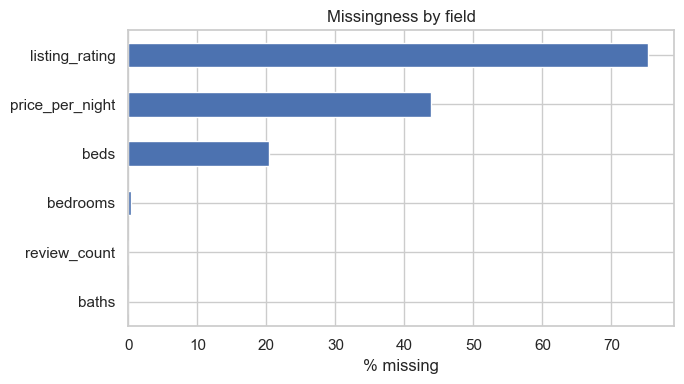

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
missing.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("Missingness by field")
plt.tight_layout()
plt.show()

## 3. Univariate distributions

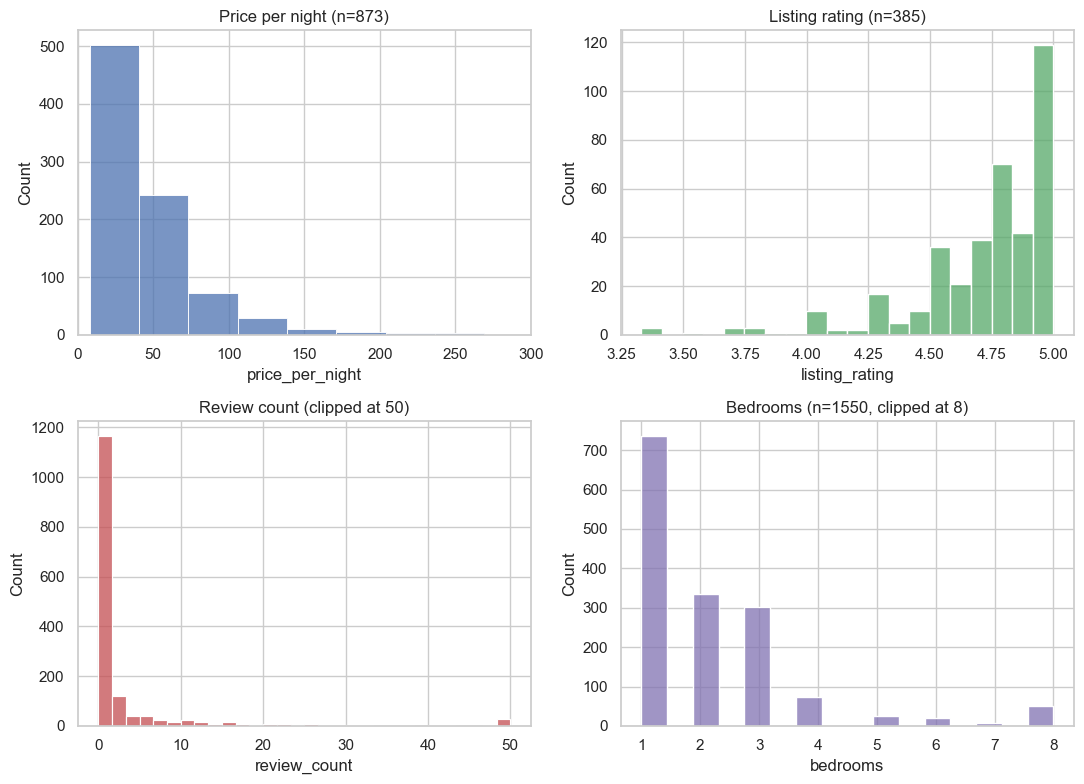

,price_per_night,listing_rating,review_count,bedrooms,beds,baths
count,873.00,385.00,1556.00,1550.00,1240.00,1556.00
mean,48.33,4.72,3.82,2.45,2.65,2.34
std,60.33,0.31,13.08,3.71,4.01,3.28
min,8.00,3.33,0.00,1.00,1.00,0.00
25%,23.00,4.60,0.00,1.00,1.00,1.00
50%,36.00,4.80,0.00,2.00,2.00,1.50
75%,57.00,5.00,2.00,3.00,3.00,3.00
max,1314.00,5.00,165.00,50.00,50.00,50.00


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(listings["price_per_night"].dropna(), bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title(f"Price per night (n={listings['price_per_night'].notna().sum()})")
axes[0, 0].set_xlim(0, 300)

sns.histplot(listings["listing_rating"].dropna(), bins=20, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title(f"Listing rating (n={listings['listing_rating'].notna().sum()})")

sns.histplot(listings["review_count"].clip(upper=50), bins=30, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Review count (clipped at 50)")

sns.histplot(listings["bedrooms"].dropna().clip(upper=8), bins=16, ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title(f"Bedrooms (n={listings['bedrooms'].notna().sum()}, clipped at 8)")

plt.tight_layout()
plt.show()

listings[["price_per_night", "listing_rating", "review_count", "bedrooms", "beds", "baths"]].describe().round(2)

## 4. Division-level breakdown

Restricted to the 8 real Bangladesh divisions (`is_bd_division`); the
remaining 208 listings are reverse-geocoding noise near the border (West
Bengal, Meghalaya, Tripura, Koshi) — see the plan/data-quality report.

In [6]:
div_summary = bd.groupby("principalSubdivision").agg(
    total_listings=("base_urls", "size"),
    price_known=("price_per_night", "count"),
    avg_price=("price_per_night", "mean"),
    median_price=("price_per_night", "median"),
    rating_known=("listing_rating", "count"),
    avg_rating=("listing_rating", "mean"),
    avg_reviews=("review_count", "mean"),
).round(2).sort_values("total_listings", ascending=False)
div_summary

,total_listings,price_known,avg_price,median_price,rating_known,avg_rating,avg_reviews
principalSubdivision,,,,,,,
Dhaka Division,656,461,40.88,30.0,277,4.74,6.41
Chittagong,318,275,67.12,55.0,21,4.65,0.84
Sylhet Division,158,6,36.00,20.5,12,4.44,0.54
Rajshahi Division,67,5,33.00,28.0,1,4.80,0.19
Barisal Division,52,2,121.00,121.0,1,5.00,0.06
Khulna Division,52,16,57.31,42.0,3,4.52,0.56
Rangpur Division,24,4,38.00,39.5,0,NaN,0.04
Mymensingh Division,21,0,NaN,NaN,1,4.50,0.24


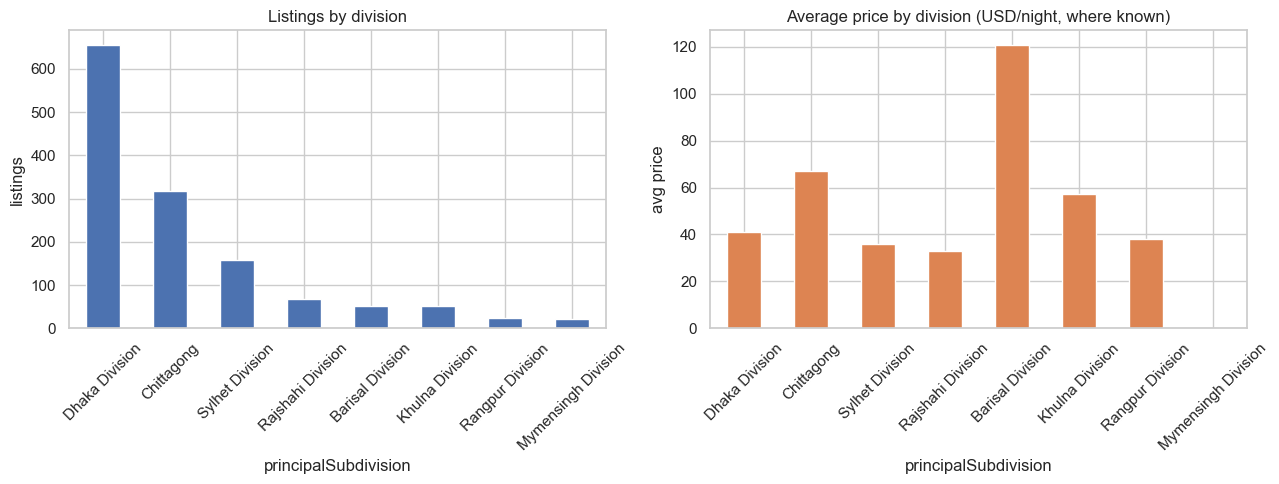

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

div_summary["total_listings"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Listings by division")
axes[0].set_ylabel("listings")

div_summary["avg_price"].plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Average price by division (USD/night, where known)")
axes[1].set_ylabel("avg price")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

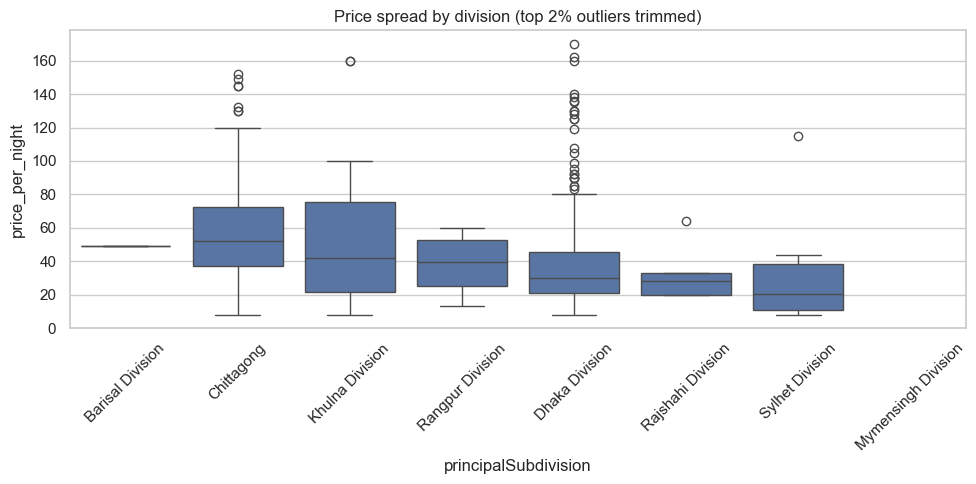

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
order = bd.groupby("principalSubdivision")["price_per_night"].median().sort_values(ascending=False).index
sns.boxplot(
    data=bd[bd["price_per_night"] < bd["price_per_night"].quantile(0.98)],
    x="principalSubdivision", y="price_per_night", order=order, ax=ax,
)
ax.set_title("Price spread by division (top 2% outliers trimmed)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Host overview

In [9]:
listings_per_host = listings["host_link"].value_counts()
print(f"distinct hosts: {len(hosts)}")
print(f"hosts with >1 listing: {(listings_per_host > 1).sum()} / {len(listings_per_host)}")
print(f"largest host: {listings_per_host.max()} listings")
print()
print("host_rating:\n", hosts["host_rating"].describe().round(2))
print()
print("host_response_rate (listing-level attribute, not host-level):\n",
      listings["host_response_rate"].describe().round(2))
print()
for col in ["host_verified_identity", "host_verified_email", "host_verified_phone", "host_verified_work_email"]:
    print(f"{col}: {hosts[col].mean()*100:.1f}%")

distinct hosts: 849
hosts with >1 listing: 193 / 849
largest host: 217 listings

host_rating:
 count    428.00
mean       4.64
std        0.58
min        1.00
25%        4.53
50%        4.80
75%        5.00
max        5.00
Name: host_rating, dtype: float64

host_response_rate (listing-level attribute, not host-level):
 count    1012.00
mean       82.30
std        26.33
min         8.00
25%        50.00
50%       100.00
75%       100.00
max       100.00
Name: host_response_rate, dtype: float64

host_verified_identity: 99.4%
host_verified_email: 80.1%
host_verified_phone: 99.8%
host_verified_work_email: 3.2%


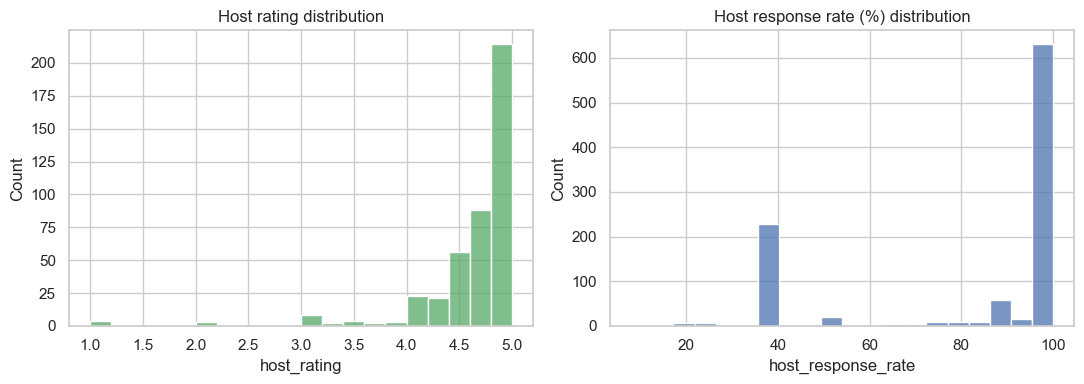

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(hosts["host_rating"].dropna(), bins=20, ax=axes[0], color="#55A868")
axes[0].set_title("Host rating distribution")
sns.histplot(listings["host_response_rate"].dropna(), bins=20, ax=axes[1], color="#4C72B0")
axes[1].set_title("Host response rate (%) distribution")
plt.tight_layout()
plt.show()

## 6. Facilities — most common amenities

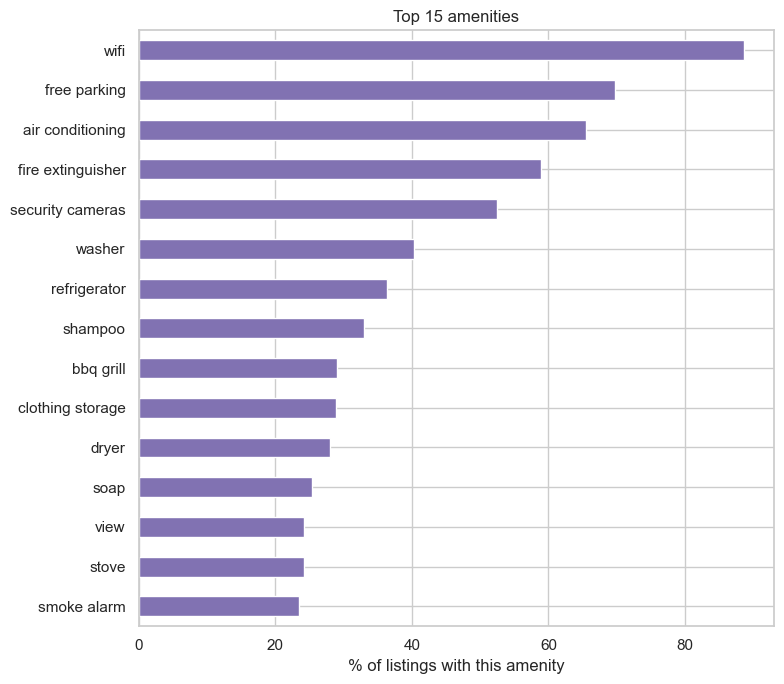

wifi                 88.6
free parking         69.7
air conditioning     65.5
fire extinguisher    58.9
security cameras     52.4
washer               40.3
refrigerator         36.4
shampoo              32.9
bbq grill            29.1
clothing storage     28.9
dryer                28.0
soap                 25.4
view                 24.2
stove                24.2
smoke alarm          23.5
dtype: float64

In [11]:
facility_cols = [c for c in facilities.columns if c not in ("base_urls", "facilities")]
top_facilities = (facilities[facility_cols].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
top_facilities.head(15).sort_values().plot.barh(ax=ax, color="#8172B2")
ax.set_xlabel("% of listings with this amenity")
ax.set_title("Top 15 amenities")
plt.tight_layout()
plt.show()

top_facilities.head(15).round(1)

## 7. Correlation between numeric fields

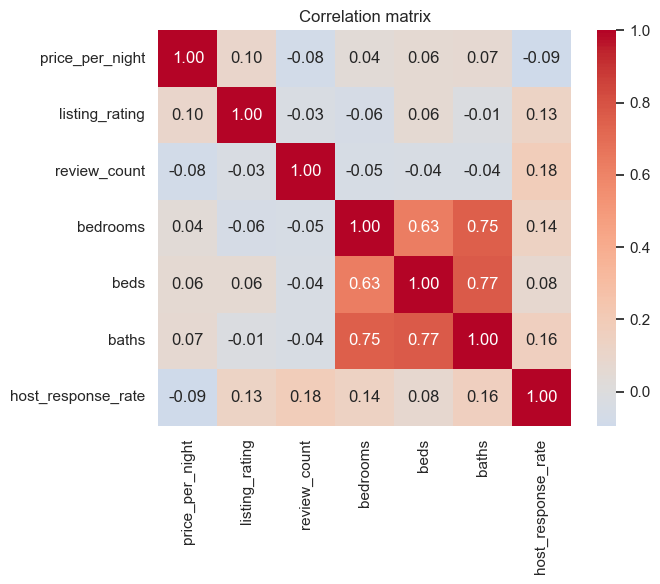

In [12]:
corr_cols = ["price_per_night", "listing_rating", "review_count", "bedrooms", "beds", "baths", "host_response_rate"]
corr = listings[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## 8. Review demand trend

Coverage caveat: review-level detail exists for 520 of 1,556 listings
(~33%) — this is a supplementary signal, not a national one.

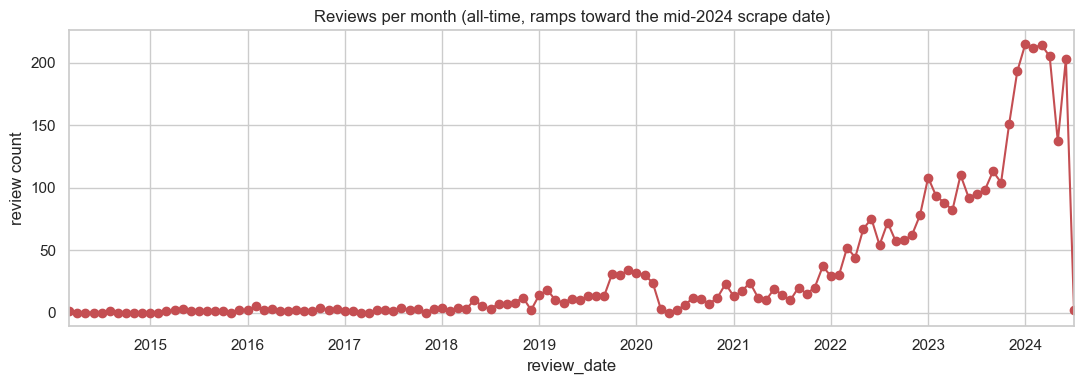

rating distribution from review-level data:


reviewer_rating
1      66
2      47
3     170
4     518
5    3097
Name: count, dtype: int64

In [13]:
monthly = reviews.set_index("review_date").resample("MS").size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker="o", color="#C44E52")
ax.set_title("Reviews per month (all-time, ramps toward the mid-2024 scrape date)")
ax.set_ylabel("review count")
plt.tight_layout()
plt.show()

print("rating distribution from review-level data:")
reviews["reviewer_rating"].value_counts().sort_index()

## 9. Cross-tab: bedrooms x division (avg price)

In [14]:
bd_valid_bed = bd[bd["bedrooms"].between(0, 5)]
ct = bd_valid_bed.pivot_table(
    index="principalSubdivision", columns="bedrooms", values="price_per_night", aggfunc="mean"
).round(0)
ct

bedrooms,1.0,2.0,3.0,4.0,5.0
principalSubdivision,,,,,
Barisal Division,49.0,193.0,NaN,NaN,NaN
Chittagong,60.0,79.0,61.0,101.0,50.0
Dhaka Division,30.0,38.0,50.0,87.0,96.0
Khulna Division,55.0,24.0,35.0,160.0,160.0
Rajshahi Division,NaN,37.0,33.0,20.0,NaN
Rangpur Division,29.0,13.0,NaN,55.0,NaN
Sylhet Division,21.0,NaN,44.0,8.0,NaN


## Summary of what stood out

- Price known for 56% of listings, rating known for only ~25% (after
  excluding the parser's residual garbage) — treat any "average price"
  figure as an estimate over a subset, not the full market.
- Dhaka and Chittagong dominate by volume and are the only divisions with
  enough price/rating coverage to trust division-level averages; the other
  6 divisions have too few observations for confident comparison.
- Host concentration is real: 193 of 849 hosts (23%) run more than one
  listing, one host alone runs 217 — relevant for the local decision-support
  module (should probably surface "is this a professional multi-listing
  operator or a single-property host" per area).
- WiFi, free parking, and air conditioning are near-universal (65-89%);
  fire safety and security features are present in roughly half of
  listings — a reasonable "baseline expectation" bar for a new listing.
- Review volume ramps up steadily into mid-2024, consistent with the scrape
  date rather than showing a demand collapse or spike.